# 07221203_2025 — dump 1 noise-pulse survey

Series `07221203_2025`, dump `F0001` (Run76: Side2, PuBe/Pb&poly lead-stack/borax,
-83.2 V). Picking out clean noise traces on **Detector 0, Channel 0 only** as a starting
point for a PSD study. Run with the `darkmatter_cli_env` conda environment.

Uses the shared `python/` library (`pulse_io`/`pulse_quantities`/`pulse_cuts`) instead
of ad-hoc per-trace loops — see `python/README.md` for the conventions.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "python"))

from nsdf_dark_matter.idx import load_all_data

import numpy as np
import matplotlib.pyplot as plt

import pulse_io as pio
import pulse_quantities as pq
import pulse_cuts as pc
from pulse_config import PulseConfig

home_directory = Path.home()
series_path = str(home_directory) + '/idx/07221203_2025_F0001'
cdms = load_all_data(series_path)

detector_ids = cdms.get_detector_ids()
print(f"channel groups (detector_ids): {len(detector_ids)}")

channel groups (detector_ids): 4551


### Note: leading-sample glitch

A number of traces have a brief electronic glitch (a step offset) in the first few
samples, before the real baseline settles — sampled 25 random traces and found leading
runs of 1-5 anomalous samples in several of them (relative to a robust estimate from
samples 200-1000), separate from the handful of traces with a genuine pulse/drift
extending much further in. `config.glitch_samples = 10` below skips that leading run
when computing the pretrigger `bmean`/`bstd` (via `pulse_quantities`), with margin. It
does **not** fix traces where the contamination is a real pulse spanning hundreds of
samples — that's a different, legitimate problem the cut still has to handle.

In [2]:
DETECTOR = 0
CHANNEL = 0
config = PulseConfig(pretrigger_samples=1000, glitch_samples=10, sample_period_s=1.6e-6)
PRETRIGGER_SAMPLES = config.pretrigger_samples  # kept for readability in later cells

detector0_ids = pio.filter_by_detector(detector_ids, DETECTOR)
detector_id_arr, pulses = pio.load_channel_batch(cdms, detector0_ids, CHANNEL)

bmean_arr = pq.pretrigger_mean(pulses, config)
bstd_arr = pq.pretrigger_std(pulses, config)
dev_arr = pq.max_deviation(pulses, config)
ratio_arr = pq.excursion_ratio(pulses, config)

print(f"detector {DETECTOR}, channel {CHANNEL} traces: {len(detector_id_arr)}")

detector 0, channel 0 traces: 1517


## Good noise selection

Cut, relative to Detector 0/Channel 0's own distribution: `bstd` below its 75th
percentile (quiet baseline) and `ratio = dev/bstd` below its 25th percentile (no
post-baseline excursion). `dev` is measured in the post-pretrigger region only (samples
1000-4096) — measuring it over the whole trace instead puts an artificial floor around
`ratio ~ 1` regardless of threshold.

In [3]:
BSTD_CAP_PERCENTILE = 75
RATIO_THRESH_PERCENTILE = 25

good_mask = (
    pc.quiet_baseline(pulses, config, percentile=BSTD_CAP_PERCENTILE, bstd=bstd_arr)
    & pc.excursion_below_percentile(pulses, config, percentile=RATIO_THRESH_PERCENTILE, ratio=ratio_arr)
)

bstd_cap = np.percentile(bstd_arr[bstd_arr > 0], BSTD_CAP_PERCENTILE)
ratio_thresh = np.percentile(ratio_arr[np.isfinite(ratio_arr)], RATIO_THRESH_PERCENTILE)
print(f"bstd_cap={bstd_cap:.2f}, ratio_thresh={ratio_thresh:.2f}")
print(f"good noise traces: {good_mask.sum()} / {len(detector_id_arr)}")

good_detector_ids = detector_id_arr[good_mask]

bstd_cap=32.48, ratio_thresh=1.93
good noise traces: 41 / 1517


/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_71183/1942965242.py:6: UserWarning: excursion_below_percentile is marked under_development: matches the original dump1_noise 'good noise' cut, which the same notebook's widened-Cut-A investigation found is biased toward contaminated-baseline traces rather than quiet ones when used alone -- combine with quiet_baseline (already the notebook's practice) rather than relying on this in isolation
  & pc.excursion_below_percentile(pulses, config, percentile=RATIO_THRESH_PERCENTILE, ratio=ratio_arr)


In [4]:
from IPython.display import display, HTML
import csv

rows = []
for i in np.where(good_mask)[0]:
    detector_id = detector_id_arr[i]
    event_id, *_ = detector_id.split('_')
    rows.append({
        "event": event_id,
        "bstd": round(float(bstd_arr[i]), 3),
        "dev": round(float(dev_arr[i]), 3),
        "ratio": round(float(ratio_arr[i]), 3),
    })
rows.sort(key=lambda r: int(r["event"]))

csv_path = "good_noise_det0_ch0.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print(f"saved {len(rows)} rows to {csv_path} (previewing first 10 below)\n")

html = ["<table><tr>" + "".join(f"<th>{k}</th>" for k in rows[0].keys()) + "</tr>"]
for r in rows[:10]:
    html.append("<tr>" + "".join(f"<td>{v}</td>" for v in r.values()) + "</tr>")
html.append("</table>")
display(HTML("".join(html)))

saved 41 rows to good_noise_det0_ch0.csv (previewing first 10 below)



event,bstd,dev,ratio
10085,16.583,29.917,1.804
10347,29.67,41.076,1.384
10431,11.149,16.396,1.471
10508,8.755,14.722,1.682
10529,13.768,21.672,1.574
10858,27.355,45.022,1.646
11083,16.459,19.988,1.214
11114,20.081,34.366,1.711
11141,17.963,25.804,1.436
11142,24.04,31.096,1.293


## Ratio histogram, `dev > 0` only

Same idea as the ratio histogram in `dump1_noise_pulses.ipynb`, but pre-removing any
trace with `dev == 0` first: `log10(ratio)` is `-inf` for those (there happen to be none
for Detector 0/Channel 0 in this dump, but the filter guards against it regardless).

Overlaid (transparent) is the same computation with the pretrigger window shortened to
500 samples instead of 1000 (still skipping the leading glitch samples) — not carried
through the cut, just compared here to see whether the two peaks are an artifact of the
1000-sample window choice.

detector 0, channel 0 traces with dev == 0 (excluded): 0


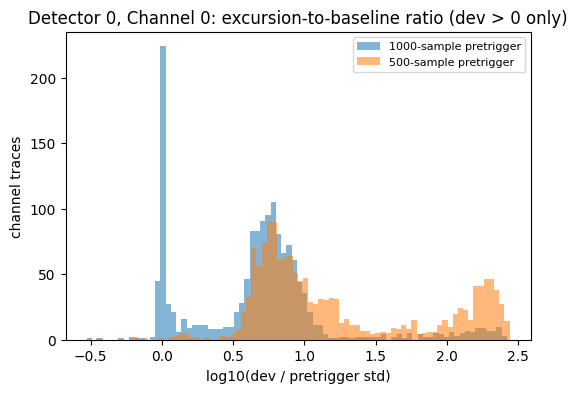

In [5]:
nonzero_dev = dev_arr > 0
print(f"detector {DETECTOR}, channel {CHANNEL} traces with dev == 0 (excluded): {(~nonzero_dev).sum()}")

# same analysis with a shorter (500-sample) pretrigger window, for comparison only --
# not carried through the rest of the notebook
config_500 = PulseConfig(pretrigger_samples=500, glitch_samples=config.glitch_samples,
                          sample_period_s=config.sample_period_s)
bstd_arr_500 = pq.pretrigger_std(pulses, config_500)
dev_arr_500 = pq.max_deviation(pulses, config_500)
ratio_arr_500 = dev_arr_500 / bstd_arr_500
nonzero_dev_500 = dev_arr_500 > 0

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log10(ratio_arr[nonzero_dev]), bins=80, alpha=0.55, label="1000-sample pretrigger")
ax.hist(np.log10(ratio_arr_500[nonzero_dev_500]), bins=80, alpha=0.55, label="500-sample pretrigger")
ax.set_xlabel("log10(dev / pretrigger std)")
ax.set_ylabel("channel traces")
ax.set_title(f"Detector {DETECTOR}, Channel {CHANNEL}: excursion-to-baseline ratio (dev > 0 only)")
ax.legend(fontsize=8)
plt.show()

## Branching point

The histogram above shows the "good noise" cut's near-`log10(ratio) = 0` selection
(used above, on the 1000-sample window) sitting right next to a spike that mostly
turns out to be pulse-contaminated baselines, while the 500-sample window's
broad hump (~0.5-1.4) stays clean and in the same place regardless of window length.
Two ways to go from here:

- **Branch 1** keeps working with the 1000-sample near-zero selection and tests
  *why* it clusters the way it does (a hypothesis, not yet verified).
- **Branch 2** instead cuts directly on the 500-sample window's clean hump as a
  candidate selection in its own right.

## Branch 1: the 1000-sample near-`log10(ratio) = 0` cut

Same idea as "Good noise selection" above, just widened (to `log10(ratio)` in
`[-0.05, 0.48)`) for enough statistics to test a hypothesis about *why* traces land
there. A few example traces, baseline-subtracted and overlaid.

In [6]:
log_ratio_arr = np.log10(ratio_arr)

cut_a_mask = nonzero_dev & (log_ratio_arr >= -0.05) & (log_ratio_arr < 0.48)
cut_a_indices = np.where(cut_a_mask)[0]

print(f"cut A (widened, near zero to 0.48): {cut_a_mask.sum()} traces")

rng = np.random.default_rng(0)
n_show = 8
cut_a_show = rng.choice(cut_a_indices, size=n_show, replace=False)

cut A (widened, near zero to 0.48): 417 traces


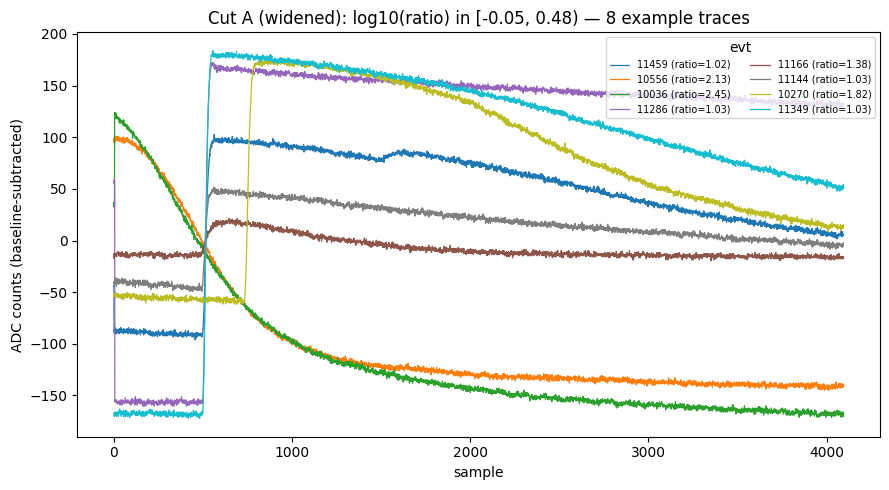

In [7]:
colors_a = plt.cm.tab10(np.linspace(0, 1, n_show))

fig, ax = plt.subplots(figsize=(9, 5))
for i, color in zip(cut_a_show, colors_a):
    trace = pulses[i] - bmean_arr[i]
    ax.plot(trace, linewidth=0.9, color=color,
             label=f"{detector_id_arr[i].split('_')[0]} (ratio={ratio_arr[i]:.2f})")
ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Cut A (widened): log10(ratio) in [-0.05, 0.48) — {n_show} example traces")
ax.legend(fontsize=7, ncol=2, loc="upper right", title="evt")
fig.tight_layout()
plt.show()

### Cut B, for comparison: the 1000-sample broad hump

Same 1000-sample window as Cut A, but the broad hump instead of the near-zero spike:
`log10(ratio)` in `[0.5, 1.0)`. Kept here as a direct comparison against Cut A above
and Branch 2 below -- same plotting style as Branch 2 (up to 30 example traces, total
retained annotated on the plot).

cut B (0.5 to 1.0): 892 / 1517 traces retained


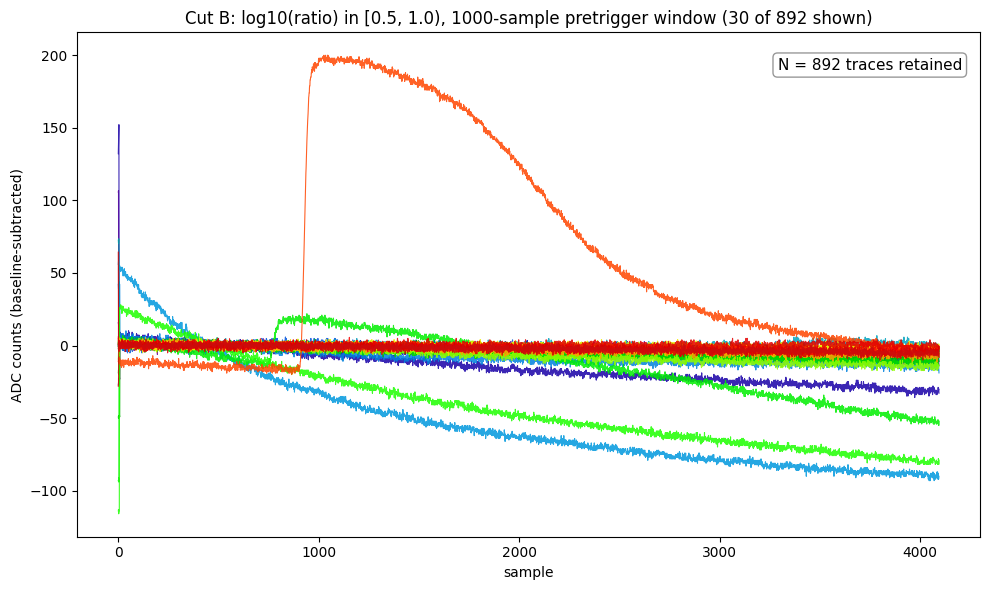

In [8]:
cut_b_mask = nonzero_dev & (log_ratio_arr >= 0.5) & (log_ratio_arr < 1.0)
cut_b_indices = np.where(cut_b_mask)[0]

print(f"cut B (0.5 to 1.0): {cut_b_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_CUT_B = min(30, len(cut_b_indices))  # as many as stay visually distinguishable
rng_b = np.random.default_rng(0)
cut_b_show = rng_b.choice(cut_b_indices, size=N_SHOW_CUT_B, replace=False)
colors_cut_b = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_CUT_B))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(cut_b_show, colors_cut_b):
    trace = pulses[i] - bmean_arr[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Cut B: log10(ratio) in [0.5, 1.0), 1000-sample pretrigger window "
             f"({N_SHOW_CUT_B} of {cut_b_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {cut_b_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

<div style="border: 2px solid #cc0000; background-color: #fff0f0; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
<span style="color: #cc0000; font-weight: bold; font-size: 1.05em;">UNVERIFIED</span><br>
This section (through the "Confirmed" cell below) rests on <code>pulse_quantities.rise_sample</code>,
which is tagged <code>under_development</code> in <code>python/pulse_quantities.py</code> — a
half-max-crossing heuristic validated on exactly this one analysis, not yet checked against
noisy or multi-peak traces. Treat the correlation and conclusion below as a working
hypothesis, not a settled result, until that function has been independently checked.
Collapsed by default in JupyterLab (click to expand) — same caveat applies wherever that
collapse doesn't render.
</div>

### Unverified: does rise time track `ratio` across all of Cut A?

The suspicion: if these pulses have similar amplitude, then how much of the 1000-sample
pretrigger window a pulse contaminates determines `bstd` (more contamination -> larger
`bstd`), and `ratio = dev/bstd` for a fixed `dev` is then *smaller* the more of the
window got contaminated — i.e. smaller `ratio` should mean an *earlier* rise (more of
the pretrigger swallowed by the pulse), not a random sample of rise times. Estimate a
per-trace "rise sample" (first post-pretrigger sample where the trace crosses half of
its own `dev`) for every trace in the widened Cut A, not just the 8 shown above, and
plot rise sample vs. `ratio`.

/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_71183/1107070782.py:1: UserWarning: rise_sample is marked under_development: fraction=0.5 half-max crossing heuristic; only validated on one exploratory analysis (07221203_2025_dump1_noise.ipynb's Cut A rise-time check) -- not yet checked against noisy/multi-peak traces
  rise_samples = pq.rise_sample(pulses[cut_a_indices], config)


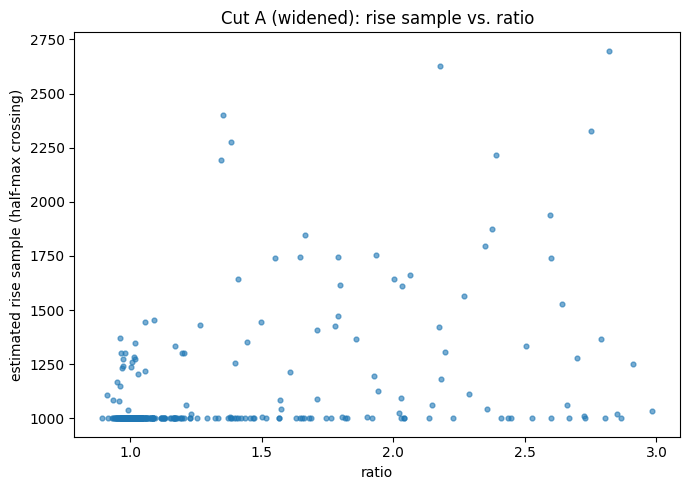

Pearson correlation (ratio, rise sample): 0.452
rise sample range: 1000 to 2698


In [9]:
rise_samples = pq.rise_sample(pulses[cut_a_indices], config)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ratio_arr[cut_a_indices], rise_samples, s=12, alpha=0.6)
ax.set_xlabel("ratio")
ax.set_ylabel("estimated rise sample (half-max crossing)")
ax.set_title("Cut A (widened): rise sample vs. ratio")
fig.tight_layout()
plt.show()

corr = np.corrcoef(ratio_arr[cut_a_indices], rise_samples)[0, 1]
print(f"Pearson correlation (ratio, rise sample): {corr:.3f}")
print(f"rise sample range: {rise_samples.min()} to {rise_samples.max()}")

**Confirmed — the original narrow slice was hiding the spread, not revealing a real
clustering.** Correlation of 0.45 between `ratio` and rise sample, and rise samples
now span 1000 to 2698 (vs. everything piling up around sample 500-600 in the original
narrow `[-0.05, 0.05)` slice). The scatter has two components:

- A large group sitting exactly at `rise_sample = 1000` across a wide range of `ratio`
  (roughly 0.9 to 2.5). This is a floor artifact of the detection method, not a real
  clustering: these pulses already crossed half-max *before* sample 1000, inside the
  pretrigger window itself, so "first post-pretrigger crossing" reports the boundary
  rather than the true onset. These are exactly the fully-pretrigger-contaminated cases
  the earlier note described.
- A clear rising trend above that floor: traces with `ratio` from ~1.3 up to ~2.9 have
  rise samples spreading smoothly from ~1200 out to ~2700. For pulses of similar
  amplitude, less of the pretrigger window gets contaminated the later the pulse
  actually rises — smaller contamination means smaller `bstd`, which (for similar `dev`)
  means *larger* `ratio`. That's exactly the mechanism proposed, and it's what's in the
  data once the cut isn't narrow enough to hide it.

## Branch 2: cut on the 500-sample window, `log10(ratio)` in `[0.5, 1.4)`

Why not just keep refining Branch 1: `dev` is the *max* of ~3000 post-baseline samples,
so even pure Gaussian noise is expected to land around `ratio ~ 3-8` by extreme-value
statistics — a trace only reaches `ratio ~ 1` (Branch 1's selection) if its pretrigger
window is itself already contaminated (part of a pulse or a slow transition inflating
`bstd`), not because it's unusually quiet. The 500-sample histogram overlay above
showed exactly this: the near-zero spike vanishes at 500 samples, while the broad hump
stays in place regardless of window length — that hump is the genuinely quiet
population.

This branch cuts directly on that hump instead: `log10(ratio_arr_500)` in
`[0.5, 1.4)`, `dev_500 > 0`. As many example traces as stay visually distinguishable
are overlaid below, with the *total* number retained by the cut annotated on the plot
(not just the number shown).

In [10]:
bmean_arr_500 = pq.pretrigger_mean(pulses, config_500)

log_ratio_arr_500 = np.log10(ratio_arr_500)

branch2_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 0.5) & (log_ratio_arr_500 < 1.4)
branch2_indices = np.where(branch2_mask)[0]

print(f"branch 2 (500-sample window, log10(ratio) in [0.5, 1.4)): "
      f"{branch2_mask.sum()} / {len(detector_id_arr)} traces retained")

branch 2 (500-sample window, log10(ratio) in [0.5, 1.4)): 1012 / 1517 traces retained


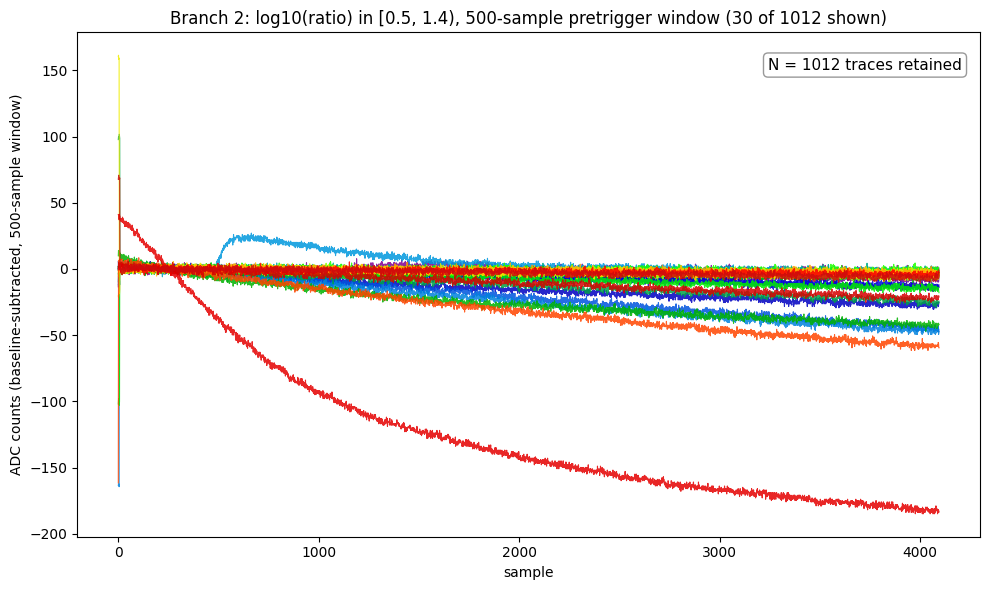

In [11]:
N_SHOW_BRANCH2 = min(30, len(branch2_indices))  # as many as stay visually distinguishable

rng2 = np.random.default_rng(0)
branch2_show = rng2.choice(branch2_indices, size=N_SHOW_BRANCH2, replace=False)
colors_branch2 = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_BRANCH2))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(branch2_show, colors_branch2):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Branch 2: log10(ratio) in [0.5, 1.4), 500-sample pretrigger window "
             f"({N_SHOW_BRANCH2} of {branch2_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {branch2_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

### Branch 2, shoulder: `log10(ratio)` in `[1.0, 1.4)`

The upper shoulder of Branch 2's own range -- same 500-sample window, same cut family,
just the higher-`ratio` slice of it on its own, to see whether it still looks like the
same clean population or starts drifting toward something else.

branch 2 shoulder (1.0 to 1.4): 268 / 1517 traces retained


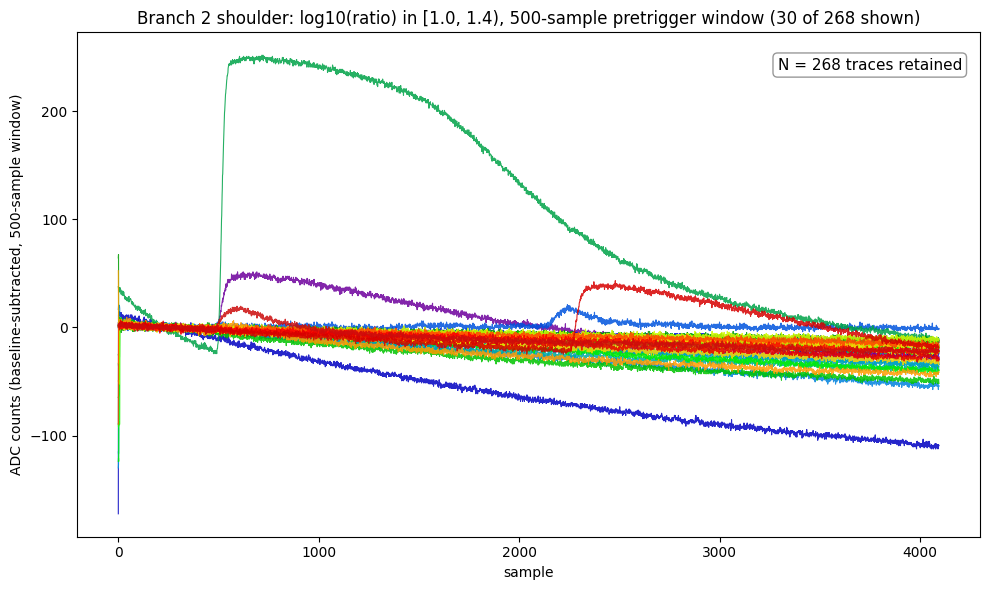

In [12]:
shoulder_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 1.0) & (log_ratio_arr_500 < 1.4)
shoulder_indices = np.where(shoulder_mask)[0]

print(f"branch 2 shoulder (1.0 to 1.4): {shoulder_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_SHOULDER = min(30, len(shoulder_indices))  # as many as stay visually distinguishable
rng_shoulder = np.random.default_rng(0)
shoulder_show = rng_shoulder.choice(shoulder_indices, size=N_SHOW_SHOULDER, replace=False)
colors_shoulder = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_SHOULDER))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(shoulder_show, colors_shoulder):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Branch 2 shoulder: log10(ratio) in [1.0, 1.4), 500-sample pretrigger window "
             f"({N_SHOW_SHOULDER} of {shoulder_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {shoulder_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

### Branch 2, high tail: `log10(ratio) >= 2.0`

Well outside Branch 2's own `[0.5, 1.4)` selection -- events with a much larger
post-baseline excursion relative to the (500-sample) pretrigger scatter. Same window,
same `dev_500 > 0` filter, no upper bound.

branch 2 high tail (>= 2.0): 346 / 1517 traces retained


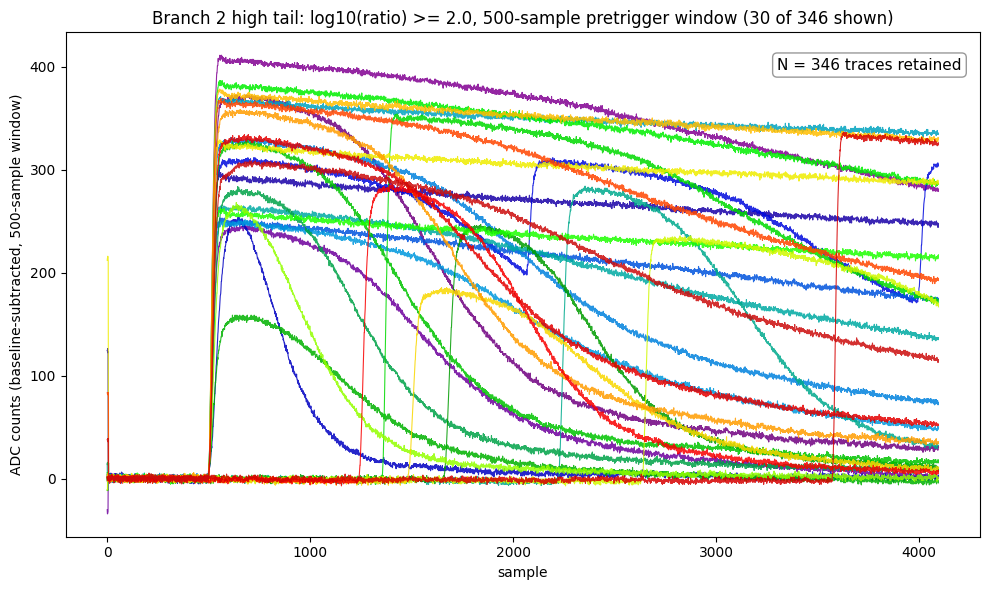

In [13]:
high_tail_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 2.0)
high_tail_indices = np.where(high_tail_mask)[0]

print(f"branch 2 high tail (>= 2.0): {high_tail_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_HIGH_TAIL = min(30, len(high_tail_indices))  # as many as stay visually distinguishable
rng_high_tail = np.random.default_rng(0)
high_tail_show = rng_high_tail.choice(high_tail_indices, size=N_SHOW_HIGH_TAIL, replace=False)
colors_high_tail = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_HIGH_TAIL))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(high_tail_show, colors_high_tail):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Branch 2 high tail: log10(ratio) >= 2.0, 500-sample pretrigger window "
             f"({N_SHOW_HIGH_TAIL} of {high_tail_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {high_tail_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

## "Best" noise examples: `log10(ratio)` in `[0.5, 1.0)`

The narrower core of Branch 2's own range (500-sample window), stopping short of the
shoulder (`[1.0, 1.4)`, shown above to already have some contamination creeping in) --
the part of the clean hump furthest from either failure mode.

In [ ]:
best_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 0.5) & (log_ratio_arr_500 < 1.0)
best_indices = np.where(best_mask)[0]

print(f"best noise examples (0.5 to 1.0): {best_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_BEST = min(30, len(best_indices))  # as many as stay visually distinguishable
rng_best = np.random.default_rng(0)
best_show = rng_best.choice(best_indices, size=N_SHOW_BEST, replace=False)
colors_best = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_BEST))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(best_show, colors_best):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"'Best' noise examples: log10(ratio) in [0.5, 1.0), 500-sample pretrigger window "
             f"({N_SHOW_BEST} of {best_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {best_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

## Tightened further: `log10(ratio)` in `[0.5, 0.7)`

Narrower still than the "best" selection above -- the bottom fifth of Branch 2's full
`[0.5, 1.4)` range, closest to the extreme-value-statistics floor for pure noise.

In [ ]:
tight_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 0.5) & (log_ratio_arr_500 < 0.7)
tight_indices = np.where(tight_mask)[0]

print(f"tightened (0.5 to 0.7): {tight_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_TIGHT = min(30, len(tight_indices))  # as many as stay visually distinguishable
rng_tight = np.random.default_rng(0)
tight_show = rng_tight.choice(tight_indices, size=N_SHOW_TIGHT, replace=False)
colors_tight = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_TIGHT))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(tight_show, colors_tight):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Tightened: log10(ratio) in [0.5, 0.7), 500-sample pretrigger window "
             f"({N_SHOW_TIGHT} of {tight_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {tight_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()